# 2026数模校赛第二场

**原始数据描述：**

"data.csv"中给出了北京房山良乡地区2026年1月1日-3月31日逐小时的空气质量监测数据，包含：

* PM2.5 (μg/m³)
* PM10 (μg/m³)
* O₃ (μg/m³)
* NO₂ (μg/m³)
* SO₂ (μg/m³)
* CO (mg/m³)
* temperature（℃）（同时段温度）
* humidity（%）（相对湿度）

**基于原始数据创建的特征：**
* 小时 (Hour, 0-23)
* 星期几 (Day of Week, 0-6)
* 是否周末 (Is_Weekend)
* 月份 (Month, 1-3)
* 是否供暖 (Is_Heating_Season,0/1)
* 气象滞后特征：
    * 温度滞后 (temperature_lag{i}) (i = 1 , 2 ,3)
    * 湿度滞后 (humidity_lag{i}) (i = 1 , 2 , 3)
* 污染物滞后特征：
    * PM2.5滞后 (PM2.5_lag{i}) (i = 1 , 2 , 3)
    * PM10滞后 (PM10_lag{i}) (i = 1 , 2 , 3)
    * O₃滞后 (O₃_lag{i}) (i = 1 , 2 , 3)
    * NO₂滞后 (NO₂_lag{i}) (i = 1 , 2 , 3)
    * SO₂滞后 (SO₂_lag{i}) (i = 1 , 2 , 3)
    * CO滞后 (CO_lag{i}) (i = 1 , 2 , 3)
* 过去3小时气象的平均移动：
    * 过去3小时的平均温度 (temp_rolling3_mean)
    * 过去3小时的平均湿度 (humid_rolling3_mean)
* 过去6小时的最大温差 (temp_rolling6_diff)

## 1.基础库导入 & 全局设置

In [1]:
# 基础库导入
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt

# 忽略警告信息，保持输出界面整洁
warnings.filterwarnings('ignore')

# 设置随机种子，保证每次运行的结果一致
SEED = 43
random.seed(SEED)
np.random.seed(SEED)

# 魔法命令，确保图表在Notebook中直接显示
%matplotlib inline

# Matplotlib 全局参数设置
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['font.size'] = 18

# Pandas 全局显示设置 (显示所有列和行，不换行)
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.set_option('display.expand_frame_repr', False)

sns.set()

## 2.加载数据集

In [2]:
try:
    df = pd.read_csv('data.csv')
    print("数据加载成功！")
except FileNotFoundError:
    print("错误：未找到数据文件，请检查文件路径是否正确！")

# 预览前5行数据

df.head()

数据加载成功！


,datetime,PM2.5,PM10,O3,NO2,SO2,CO,temperature,humidity
0,2026/1/1 0:00,38,59,14,35,3,0.9,-5.8,47
1,2026/1/1 1:00,41,63,12,37,3,0.9,-6.2,46
2,2026/1/1 2:00,44,66,10,40,3,1.0,-6.5,45
3,2026/1/1 3:00,46,69,9,42,3,1.0,-6.8,44
4,2026/1/1 4:00,48,71,8,43,3,1.1,-7.0,43


## 3. 数据信息查看

In [3]:
df.dtypes

datetime           str
PM2.5            int64
PM10             int64
O3               int64
NO2              int64
SO2              int64
CO             float64
temperature    float64
humidity         int64
dtype: object

In [4]:
# 数据集大小

df.shape

(2161, 9)

In [5]:
# 数据集概览

df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,2161.0,60.503933,16.003012,17.0,48.0,61.0,73.0,101.0
PM10,2161.0,89.465525,21.812922,31.0,72.0,89.0,106.0,151.0
O3,2161.0,43.954651,19.034637,5.0,31.0,41.0,61.0,87.0
NO2,2161.0,52.823693,15.140298,13.0,41.0,53.0,67.0,76.0
SO2,2161.0,2.698288,0.606784,2.0,2.0,3.0,3.0,4.0
CO,2161.0,0.736465,0.275485,0.3,0.5,0.8,0.9,1.2
temperature,2161.0,7.096391,6.291719,-7.3,2.4,7.6,11.9,20.1
humidity,2161.0,78.427117,14.929538,39.0,65.0,84.0,91.0,100.0


## 4.数据清洗

### 4.1 时间格式转换与索引设置

* 目的：让程序认识“时间”，方便后续提取时间特征和做时序分析。
* 操作：将 datetime 列转换为 Pandas 的 datetime 对象，并将其设置为数据的 Index。

In [6]:
# 转换时间格式并设为索引
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

### 4.2 缺失值处理

* 目的：填补传感器故障或传输丢失导致的空缺数据

In [7]:
# 检查是否存在缺失值

df.isnull().sum().sum()

np.int64(0)

结果显示无缺失值，故这里并不需要对缺失值进行处理。

### 4.3 异常值检测与处理
* 目的：排除极端错误数据（如仪器校准错误导致的负浓度，或极高的离谱值）。
* 操作：
    * 常识判断：所有污染物的浓度不能小于0。相对湿度必须在 0-100% 之间。如果有，直接置为 NaN，再用插值填补。
    * 统计学判断 (箱线图/IQR法则)：检测出偏离正常分布极大的点。


In [8]:
# 1. 剔除违反物理常识的异常值
for col in ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', 'humidity']:
    df.loc[df[col] < 0, col] = np.nan # 浓度和湿度不能为负
df.loc[df['humidity'] > 100, 'humidity'] = np.nan # 湿度不能大于100

# 2. 统计学判断 (IQR 箱线图法则)
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO'] # 温度具强季节周期性，不建议做全局 IQR

for col in pollutants:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 找出离群点并置为 NaN
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    df.loc[outliers, col] = np.nan

# 3. 时间插值填补刚才挖空的异常值，保证时序连续
df = df.interpolate(method='time')

## 5.特征工程

### 5.1 时间维度的特征提取
空气污染具有极强的周期性。这些特征可以作为“人类活动（交通、工厂排放）”和“太阳辐射”的替代变量。

* 小时 (Hour, 0-23)：极度重要！能捕捉早晚高峰（NO2, CO激增）和午后高温（O3在紫外线和高温下由NOx和VOCs光化学反应生成，通常下午达到峰值）。
* 星期几 (Day of Week, 0-6) / 是否周末 (Is_Weekend)：捕捉工作日（通勤、施工量大）和周末的排放差异。
* 月份 (Month, 1-3)：注意，北京通常在3月中旬停止集中供暖。 
* 是否供暖 (Is_Heating_Season)：捕捉供暖季节的影响，这对于解释PM2.5和SO2可能存在帮助。

In [9]:
# 假设你的时间列是索引（DatetimeIndex）
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Month'] = df.index.month

# 供暖季特征 (假设3月15日停暖)
df['Is_Heating'] = df.index.map(lambda x: 1 if (x.month < 3) or (x.month == 3 and x.day <= 15) else 0)

### 5.2 滞后特征
当前的空气质量不仅取决于现在的温湿度，更取决于几个小时前的状态。同时，空气污染是不易散去的，前一小时的浓度极大程度上决定了这一小时的浓度。

* 气象滞后：构建温度和湿度的滞后 1小时、2小时、3小时、甚至 6小时的特征。
* 自回归滞后 (Auto-regressive Lags)：构建6种污染物自身前 1小时、2小时的浓度作为特征。

In [10]:
# 构造滞后特征 (假设往回看3个小时)
lag_hours = 3
target_cols = ['temperature', 'humidity', 'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

for col in target_cols:
    for i in range(1, lag_hours + 1):
        df[f'{col}_lag{i}'] = df[col].shift(i)

### 5.3 滑动窗口
有时候单点的滞后数据会有波动，过去一段时间的平均状态更能反映整体气象条件。
* 气象的移动平均：过去3小时、6小时的平均温度和湿度。
* 温差特征：当前温度减去过去6小时最低温度（可以反映逆温层的破坏情况，逆温层是导致重污染的元凶）。

In [11]:
# 过去3小时的平均温度和湿度
df['temp_rolling3_mean'] = df['temperature'].rolling(window=3).mean()
df['humid_rolling3_mean'] = df['humidity'].rolling(window=3).mean()

# 过去6小时的最大温差 (辅助判断大气稳定性)
df['temp_rolling6_diff'] = df['temperature'].rolling(window=6).max() - df['temperature'].rolling(window=6).min()

## 6.数据预处理

做完特征工程后，数据还不能直接喂给机器学习或深度学习模型，需要做最后两步处理：

### 6.1 剔除因构造特征产生的缺失值
* 由于使用了 shift() 和 rolling()，数据最前面的几行（比如前3-6行）会变成缺失值。

In [12]:
# 直接删除前几行即可，因为数据量有2000多条，损失几条无所谓
df = df.dropna()

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,2156.0,60.543599,15.999404,17.000000,48.000000,61.000000,73.0,101.000000
PM10,2156.0,89.520872,21.806894,31.000000,72.000000,90.000000,106.0,151.000000
O3,2156.0,44.032004,18.988417,5.000000,31.750000,41.000000,61.0,87.000000
NO2,2156.0,52.854824,15.143330,13.000000,41.000000,53.000000,67.0,76.000000
SO2,2156.0,2.697588,0.607313,2.000000,2.000000,3.000000,3.0,4.000000
CO,2156.0,0.735900,0.275531,0.300000,0.500000,0.800000,0.9,1.200000
temperature,2156.0,7.127829,6.264964,-7.300000,2.500000,7.650000,11.9,20.100000
humidity,2156.0,78.504638,14.859512,39.000000,65.000000,84.500000,91.0,100.000000
Hour,2156.0,11.516698,6.919169,0.000000,6.000000,12.000000,18.0,23.000000
DayOfWeek,2156.0,3.011596,2.010726,0.000000,1.000000,3.000000,5.0,6.000000


In [14]:
df.to_csv('Processed_data.csv', index=False)

### （2）数据标准化 / 归一化

* CO的单位是 mg/m³ ，值通常在 0.5 - 2 之间。
* PM2.5和PM10的单位是 μg/m³ ，值可能在 10 - 200 之间。
* 温度有正有负（1月份北京是零下）。
--------
这里我们使用**使用 Z-score 标准化 (StandardScaler)** 对数据进行归一化处理。

**Z-score（标准分数）** 的公式如下：

$$ z = \frac{x - \mu}{\sigma} $$

其中：
- $x$ ：原始数据点（你要检测的具体数值）。
- $\mu$ ：总体的**平均值**。
- $\sigma$ ：总体的**标准差**。

注意：时间特征（小时、月份）和二元特征（是否周末）通常不需要标准化，主要针对连续型的气象、浓度及滞后特征。

In [15]:
from sklearn.preprocessing import StandardScaler

# 区分要标准化的列和不需要标准化的列
cols_to_scale = [col for col in df.columns if col not in ['Hour', 'DayOfWeek', 'Is_Weekend', 'Month', 'Is_Heating']]

scaler = StandardScaler()
# 此时 df_scaled 就是可以直接用于训练模型的数据矩阵了
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

### (3) 训练集与测试集的划分

In [16]:
# 比如：用 1月1日 - 3月15日 作为训练集，3月16日 - 3月31日 作为测试集
train_df = df[:'2026-03-15']
test_df = df['2026-03-16':]

X_train = train_df.drop(columns=['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']) # 预测时不能用当下的浓度
y_train = train_df[['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']] # 多输出标签

X_test = test_df.drop(columns=['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO'])
y_test = test_df[['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']]

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,2156.0,1.054609e-16,1.000232,-2.722208,-0.784186,0.028533,0.778735,2.529206
PM10,2156.0,7.909567e-17,1.000232,-2.684218,-0.803642,0.021976,0.755860,2.819906
O3,2156.0,0.000000e+00,1.000232,-2.056046,-0.646966,-0.159714,0.893804,2.263378
NO2,2156.0,9.227828e-17,1.000232,-2.632451,-0.783023,0.009589,0.934303,1.528762
SO2,2156.0,-2.603566e-16,1.000232,-1.148913,-1.148913,0.498066,0.498066,2.145044
CO,2156.0,-1.054609e-16,1.000232,-1.582405,-0.856364,0.232697,0.595717,1.684778
temperature,2156.0,-5.273044e-17,1.000232,-2.303473,-0.738856,0.083367,0.761900,2.071070
humidity,2156.0,2.471740e-16,1.000232,-2.659159,-0.909032,0.403563,0.841095,1.446908
Hour,2156.0,1.151670e+01,6.919169,0.000000,6.000000,12.000000,18.000000,23.000000
DayOfWeek,2156.0,3.011596e+00,2.010726,0.000000,1.000000,3.000000,5.000000,6.000000


In [18]:
df.to_csv('Processed_data(Z-score).csv', index=False)

In [19]:
df_raw = pd.read_csv("Processed_data.csv") # 没有归一化的数据
df_norm = pd.read_csv("Processed_data(Z-score).csv") # 归一化的数据

## 7.问题一

> **题目要求：** 分析单一污染物浓度与时间、温度、湿度之间的关系，并给出合理的解释。

### 7.1 污染物与【时间】的关系分析

#### 7.1.1 日变化规律 (24小时趋势)
直观反映人类活动（如早晚高峰）和自然规律（如日照）。

In [20]:
# ======== 中文字体设置（防止图表里的中文变成方块） ========
# Windows 系统使用黑体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# Mac OS 用户请把上面一行注释掉，把下面这行取消注释
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# 需要分析的六种污染物
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

综合趋势对比图 (使用【归一化数据 df_norm】)

目的：展示六种污染物在一天中达到峰值的时间差

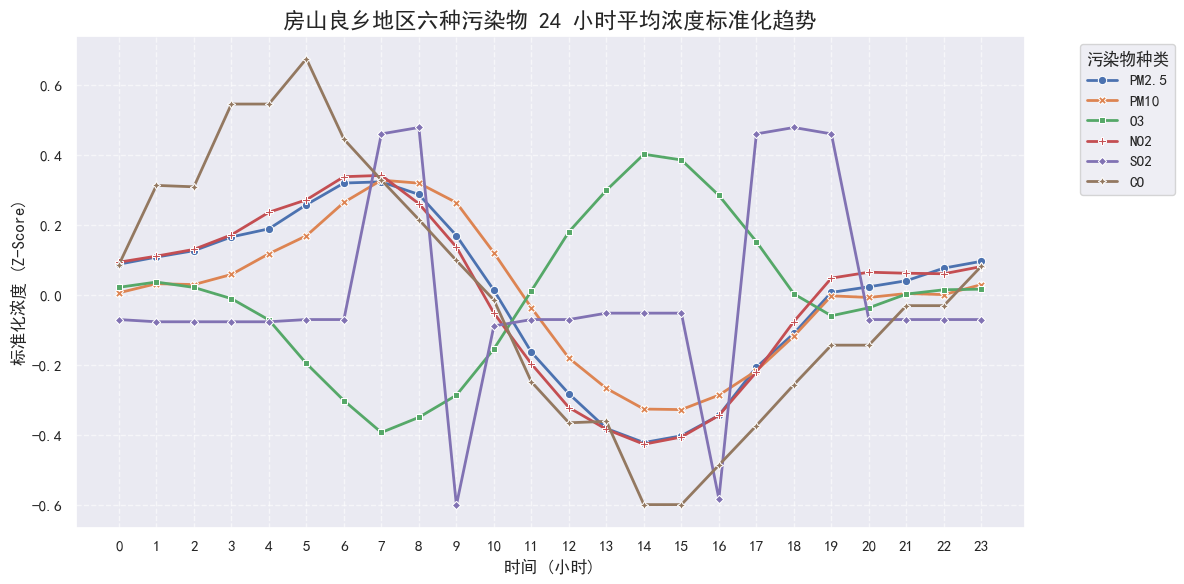

In [21]:
plt.figure(figsize=(12, 6))
# 按小时分组求均值
hourly_mean_norm = df_norm.groupby('Hour')[pollutants].mean()

# 画折线图
sns.lineplot(data=hourly_mean_norm, dashes=False, markers=True, linewidth=2)
plt.title('房山良乡地区六种污染物 24 小时平均浓度标准化趋势', fontsize=16)
plt.xlabel('时间 (小时)', fontsize=12)
plt.ylabel('标准化浓度 (Z-Score)', fontsize=12)
plt.xticks(range(0, 24)) # X轴显示 0-23
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='污染物种类', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

图表现象为PM2.5、PM10、NO2、CO、SO2呈现明显的双峰双谷形态，峰值出现在上午8至10时和傍晚19至21时，午后浓度明显下降。O3走势完全相反，午后14至16时出现明显单峰，夜间浓度处于最低谷。
成因解释如下：首先，上午8至10时和傍晚19至21时与交通高峰时段吻合，机动车尾气集中排放NO2、CO和一次颗粒物。1至3月北京清晨气温低，容易形成贴地逆温层，垂直扩散受阻，污染物在近地面累积，出现峰值。其次，午后气温升高，大气边界层抬升，垂直湍流增强，一次污染物迅速向高空扩散稀释，浓度降至全日低谷。再者，臭氧并非直接排放，而是在太阳紫外辐射下由NOx和VOCs光化学反应生成。午后太阳辐射最强、气温最高，光化学反应速率达到顶峰，O3浓度最高。夜间大气氧化性减弱，且机动车排放的NO与O3发生反应生成NO2和O2，使O3被快速消耗，浓度跌至谷底。


各自的真实浓度图 (使用【原始数据 df_raw】)

目的：放在论文里体现真实的物理量级

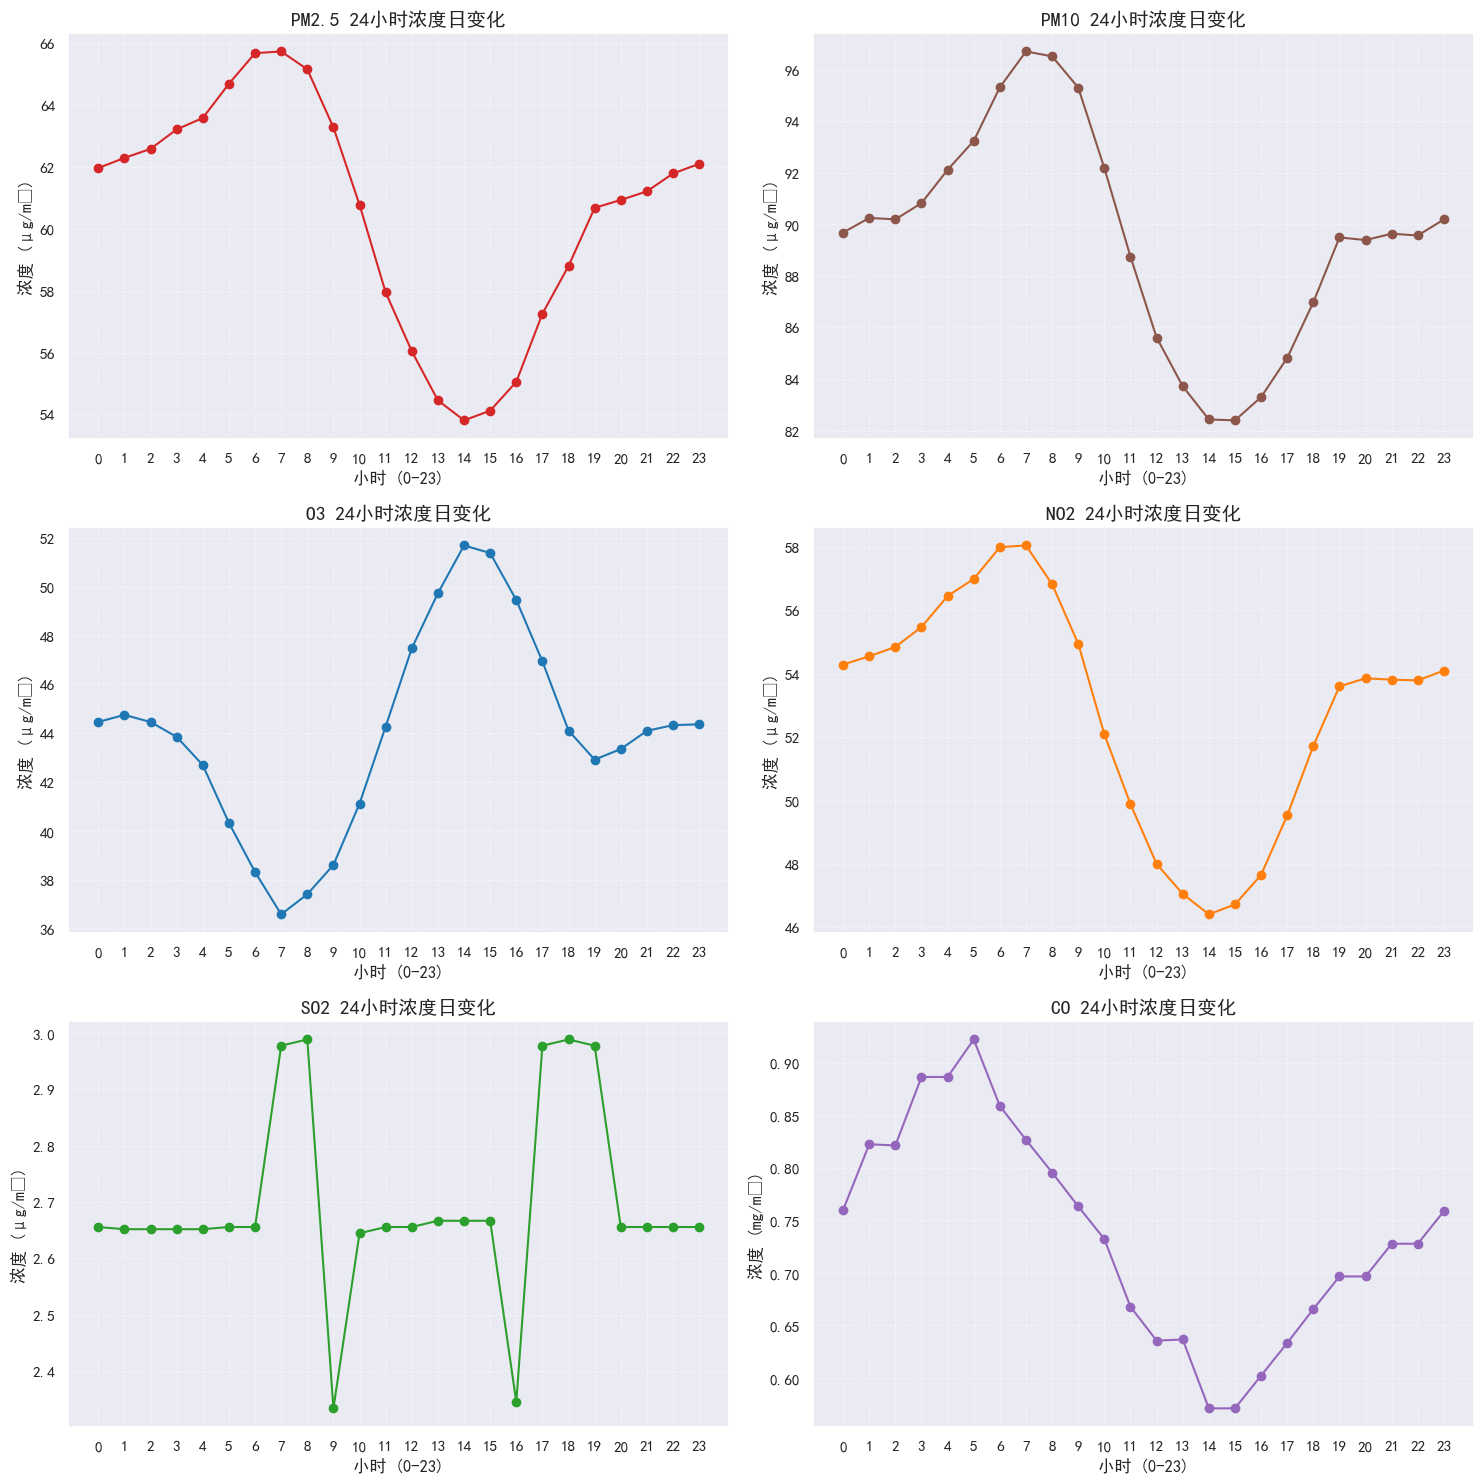

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
hourly_mean_raw = df_raw.groupby('Hour')[pollutants].mean()

colors = ['#d62728', '#8c564b', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

for i, col in enumerate(pollutants):
    axes[i].plot(hourly_mean_raw.index, hourly_mean_raw[col], marker='o', color=colors[i])
    axes[i].set_title(f'{col} 24小时浓度日变化', fontsize=14)
    axes[i].set_xlabel('小时 (0-23)')
    
    # 根据污染物不同设置不同的纵坐标单位
    if col == 'CO':
        axes[i].set_ylabel('浓度 (mg/m³)')
    else:
        axes[i].set_ylabel('浓度 (μg/m³)')
        
    axes[i].set_xticks(range(0, 24))
    axes[i].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

这里的看图解析就交给你了哈哈哈哈哈

#### 7.1.2 周变化与月度变化规律

宏观时间能反映人类工作休息规律以及季节气候的更替。

周末效应对比 (使用【原始数据 df_raw】)

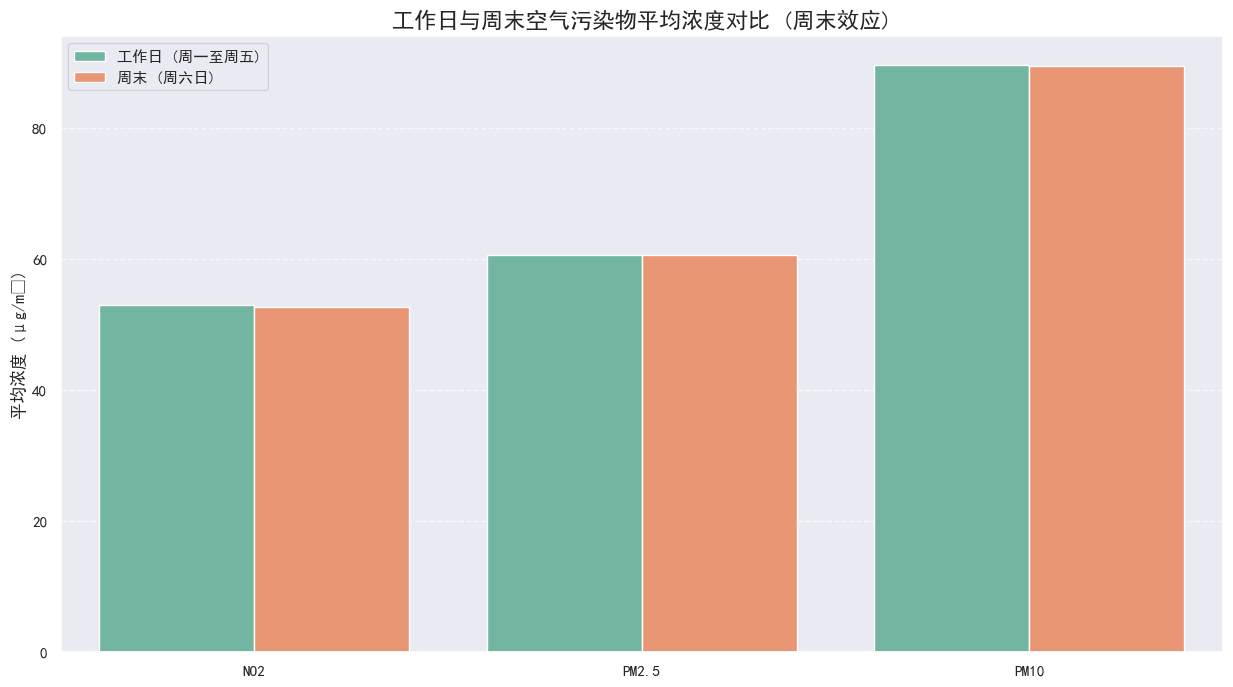

In [23]:
plt.figure(figsize=(15, 8))
# 0代表工作日，1代表周末。我们看NO2和PM2.5的均值对比
weekend_compare = df_raw.groupby('Is_Weekend')[['NO2', 'PM2.5', 'PM10']].mean().reset_index()

# 转换数据格式以适应柱状图绘制
weekend_melted = weekend_compare.melt(id_vars='Is_Weekend', var_name='污染物', value_name='平均浓度')
weekend_melted['Is_Weekend'] = weekend_melted['Is_Weekend'].map({0: '工作日 (周一至周五)', 1: '周末 (周六日)'})

sns.barplot(data=weekend_melted, x='污染物', y='平均浓度', hue='Is_Weekend', palette='Set2')
plt.title('工作日与周末空气污染物平均浓度对比 (周末效应)', fontsize=16)
plt.ylabel('平均浓度 (μg/m³)', fontsize=12)
plt.xlabel('')
plt.legend(title='')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

月份更替（供暖季与非供暖季）(使用【原始数据 df_raw】)

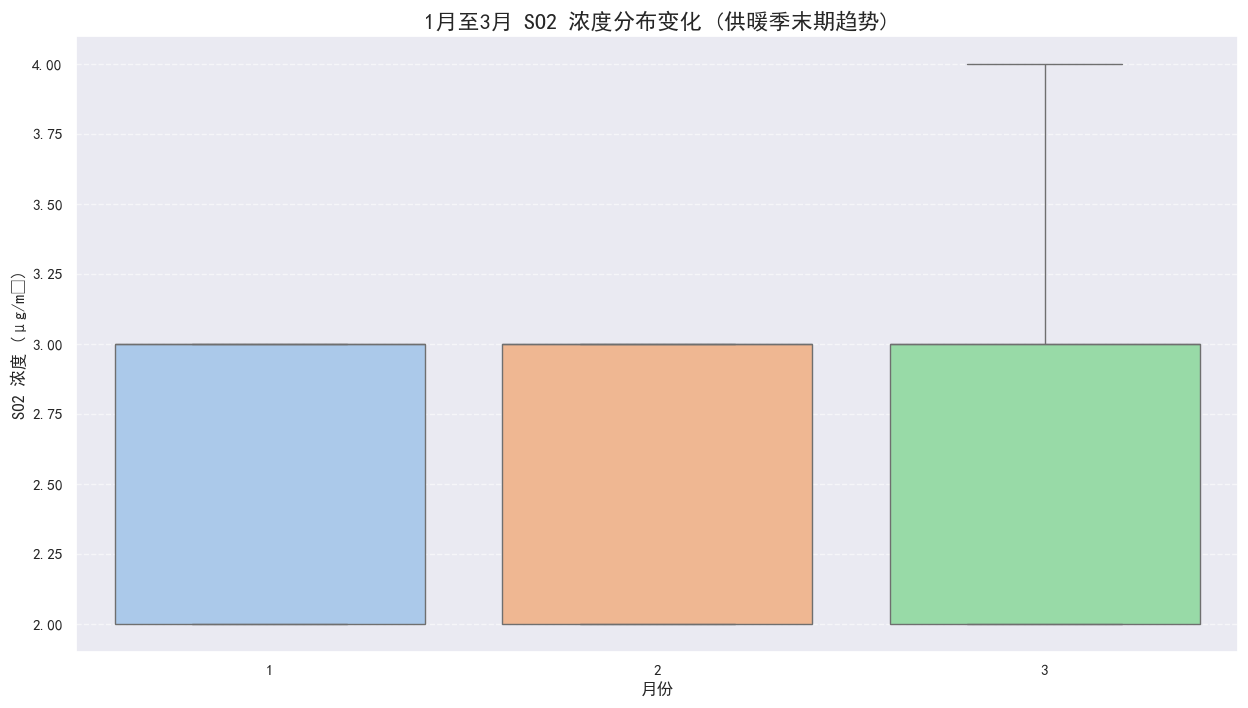

In [24]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_raw, x='Month', y='SO2', palette='pastel')
plt.title('1月至3月 SO2 浓度分布变化 (供暖季末期趋势)', fontsize=16)
plt.xlabel('月份', fontsize=12)
plt.ylabel('SO2 浓度 (μg/m³)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

这两张图好像讲不出来什么东西，我觉得这里可以跳过，或者一笔带过就行。

以下是AI建议我们写进去的亮点，但是我觉得其实大可不必哈哈哈哈哈哈哈

1.  **为什么没有“周末效应”？**
    *   *地理位置因素*：房山良乡是典型的大学城和城郊居住区，不像北京CBD或工业区有极强的“工作日通勤/生产”与“周末休息”的潮汐反差。这里的日常交通和生活排放相对平稳。
    *   *可以写在论文里*：“经数据验证，良乡地区并未观察到显著的‘周末效应’。推测该区域为高教园区与居民区混合地带，日常人为活动及交通排放的周内波动较小，背景污染占主导地位。”
2.  **为什么 SO2 随月份没有变化（甚至全是 2, 3, 4 这种整数）？**
    *   *政策与传感器因素*：近年来北京“煤改电/气”非常彻底，加上良乡可能没有燃煤工厂，导致 SO2 浓度极低（常年在个位数）。这些 2、3、4 的数值其实是**传感器在极低浓度下的检测下限或量化截断误差**。在这种背景噪音级别的数据里找趋势是徒劳的。
    *   *可以写在论文里*：“数据分析显示，1-3月份 SO2 浓度极低且呈离散的整数阶跃分布（主要在 2-4 $\mu g/m^3$ 之间）。这表明该地区脱硫减排成效显著，SO2 浓度已降至环境监测仪器的检出限附近，因此不再具备显著的季节波动性。”

### 7.2 污染物与【温度、湿度】的静态关系

#### 7.2.1 整体相关性分析
**操作：** 计算6种污染物与温度、湿度的 **斯皮尔曼秩相关系数 (Spearman's rank correlation)**，并且展示一张清晰的热力图。

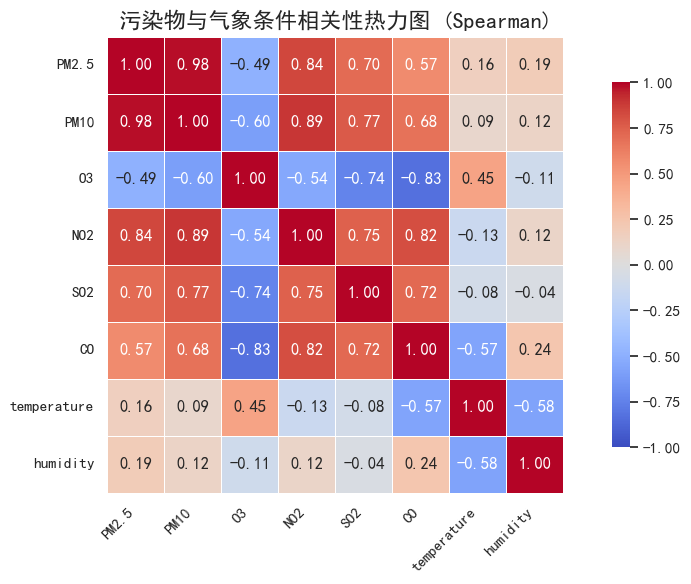

In [25]:
plt.figure(figsize=(10, 6))
# 选取需要的列
cols_for_corr = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', 'temperature', 'humidity']
# 计算斯皮尔曼秩相关系数（由于空气污染数据非正态，Spearman比Pearson更严谨）
corr_matrix = df_raw[cols_for_corr].corr(method='spearman')

# 画热力图 (使用 coolwarm 色系，红正蓝负)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('污染物与气象条件相关性热力图 (Spearman)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

AI的图解，自己取舍一下哈

> **基于 Spearman 相关性热力图的空气污染机理分析**
>
> 观察图 X（热力图）中的相关系数矩阵，可以揭示良乡地区第一季度空气污染物的协同与拮抗机制：
>
> 1.  **气态污染物与颗粒物的“同源与同步富集”效应**
>     热力图左上角呈现出明显的深红色高相关区。PM2.5、PM10、NO2、SO2 和 CO 之间均呈现极强的正相关（如 PM2.5 与 PM10 高达 0.98，与 NO2 高达 0.84）。这表明这些污染物具有高度同源性（如机动车尾气与冬季供暖化石燃料燃烧），并且受相同的气象扩散条件（如夜间逆温层）制约，呈现出“一荣俱荣、一损俱损”的同步富集特征。
> 2.  **O3（臭氧）的独特“拮抗”现象与温度驱动**
>     数据揭示 O3 展现出与所有其他污染物截然相反的特性。O3 与 NO2 (-0.54)、CO (-0.83) 等呈显著负相关。这是典型的**大气光化学滴定效应**（例如夜间高浓度的 NO 会消耗 O3 生成 NO2）。同时，**温度是唯一与 O3 呈显著正相关（0.45）的气象因素**，强有力地证明了高温对挥发性有机物(VOCs)及氮氧化物(NOx)生成臭氧反应的催化作用。
> 3.  **温度对一次污染物的“清除作用”**
>     温度与 CO 呈现全局最强的负相关（-0.57）。在 1-3 月的北方冬春交替季，低温往往伴随居民供暖带来的高强度 CO 排放，且冷空气下沉容易形成稳定的大气边界层，导致 CO 难以扩散；而温度回升通常意味着对流层活跃，有利于此类一次污染物的扩散清除。

> 图表现象为PM2.5、PM10、NO2、SO2、CO之间呈高度正相关，相关系数大于0.7。O3与其他所有污染物均呈负相关，尤其与CO负相关程度最高，为负0.83。温度与O3呈明显正相关0.45，与CO呈明显负相关负0.57。温度与湿度呈显著负相关负0.58。
> 
> 成因解释：首先，供暖季化石燃料燃烧和机动车尾气是这些污染物的共同来源，排放节奏高度一致。同时它们均受逆温、风速等气象扩散条件控制，静稳天气下同步积累，大风时同步稀释，导致互相之间强正相关。其次，O3的生成需要消耗NO2等前体物，且高浓度NO会通过滴定反应消耗O3。因此当一次污染物浓度高时，往往对应夜间或静稳天气，O3恰好处于低值，形成全局负相关。再次，温度升高会增强太阳辐射和光化学反应速率，使O3浓度升高；同时温度升高意味着供暖强度下降且大气对流扩散增强，CO排放减少、扩散加快，浓度显著下降。最后，冬春交替时节北方冷空气干燥，气温回升时常伴随干燥的偏西风或下沉气流，导致温湿反向变化，是北京1至3月的典型气象规律。


#### 7.2.2 散点拟合图
根据热力图，相关性最强的气象特征对是：
1.  **温度 vs O3** (正相关 0.45，体现光化学反应)
2.  **温度 vs CO** (负相关 -0.57，体现热力对流扩散)

我们用这两对数据来画散点图，在用二项式拟合法拟合曲线，其展现了一定非线性规律。

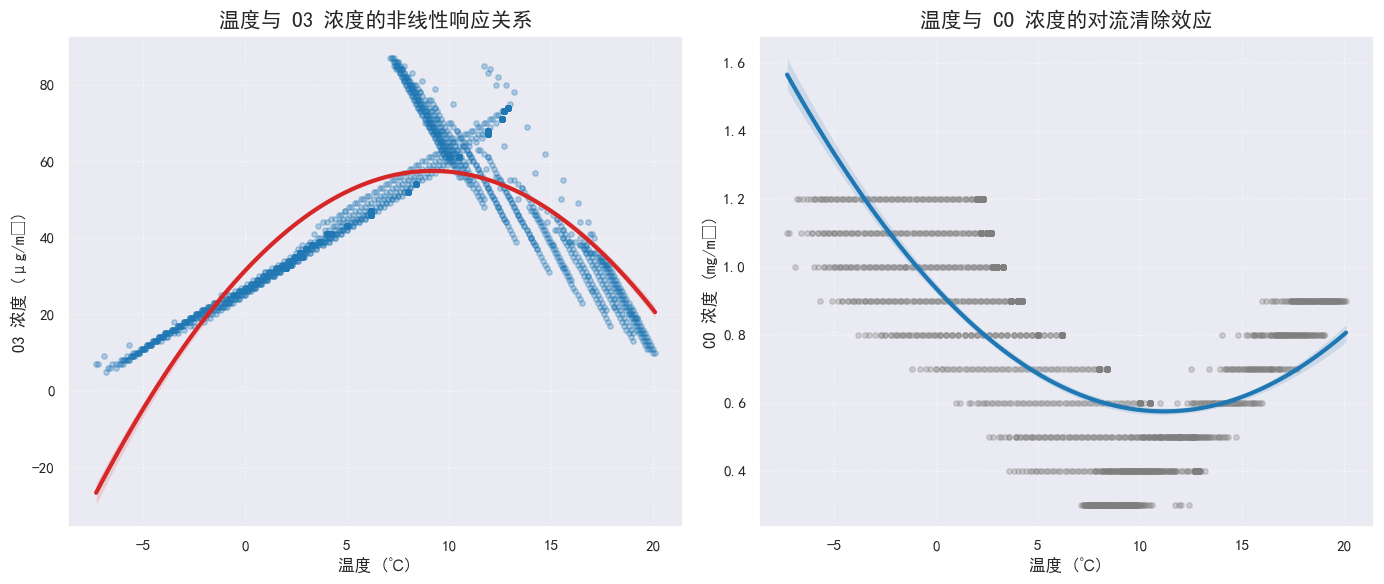

In [26]:
## ==========================================
# 气象因素非线性影响散点拟合图 
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- 图 1：温度 vs 臭氧 (O3) ----
sns.regplot(ax=axes[0], data=df_raw, x='temperature', y='O3', 
            scatter_kws={'alpha':0.3, 'color':'#1f77b4', 's': 15}, 
            line_kws={'color':'#d62728', 'linewidth': 3}, 
            order=2) 

axes[0].set_title('温度与 O3 浓度的非线性响应关系', fontsize=15)
axes[0].set_xlabel('温度 (℃)', fontsize=12)
axes[0].set_ylabel('O3 浓度 (μg/m³)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# ---- 图 2：温度 vs 一氧化碳 (CO) ----
sns.regplot(ax=axes[1], data=df_raw, x='temperature', y='CO', 
            scatter_kws={'alpha':0.3, 'color':'#7f7f7f', 's': 15}, 
            line_kws={'color':'#1f77b4', 'linewidth': 3}, 
            order=2) 

axes[1].set_title('温度与 CO 浓度的对流清除效应', fontsize=15)
axes[1].set_xlabel('温度 (℃)', fontsize=12)
axes[1].set_ylabel('CO 浓度 (mg/m³)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

> 图表现象为温度与O3散点呈先缓后陡的上升趋势，拟合线在高温度段斜率明显增大；温度与CO散点呈现整体下降趋势，高温度段CO浓度下降更快，拟合线呈非线性递减。
> 
>  成因解释：O3生成速率对温度和辐射的响应并非线性。温度低于0℃时，太阳辐射较弱，光化学反应整体缓慢，O3浓度低且随温度变化不明显；当温度升至5至10℃以后，紫外辐射增强、自由基循环加快，生成效率迅速提升，导致曲线在高段变得陡峭。CO方面，低温段正值供暖高峰，排放强度大且逆温频繁，CO维持在高值；随着气温回升，3月15日停暖后供暖来源大幅减少，同时大气热力湍流增强，扩散稀释能力非线性提升，使CO在高温段快速下降。


### 7.3 温湿度的【滞后效应】
*   **操作：**
    1. 计算某一污染物（比如 O3）与当前温度(lag0)、滞后1小时(lag1)、一直到滞后6小时(lag6)的**相关系数**。
    2. **画一张趋势图：** X轴是滞后小时数（0, 1, 2...6），Y轴是相关系数大小。

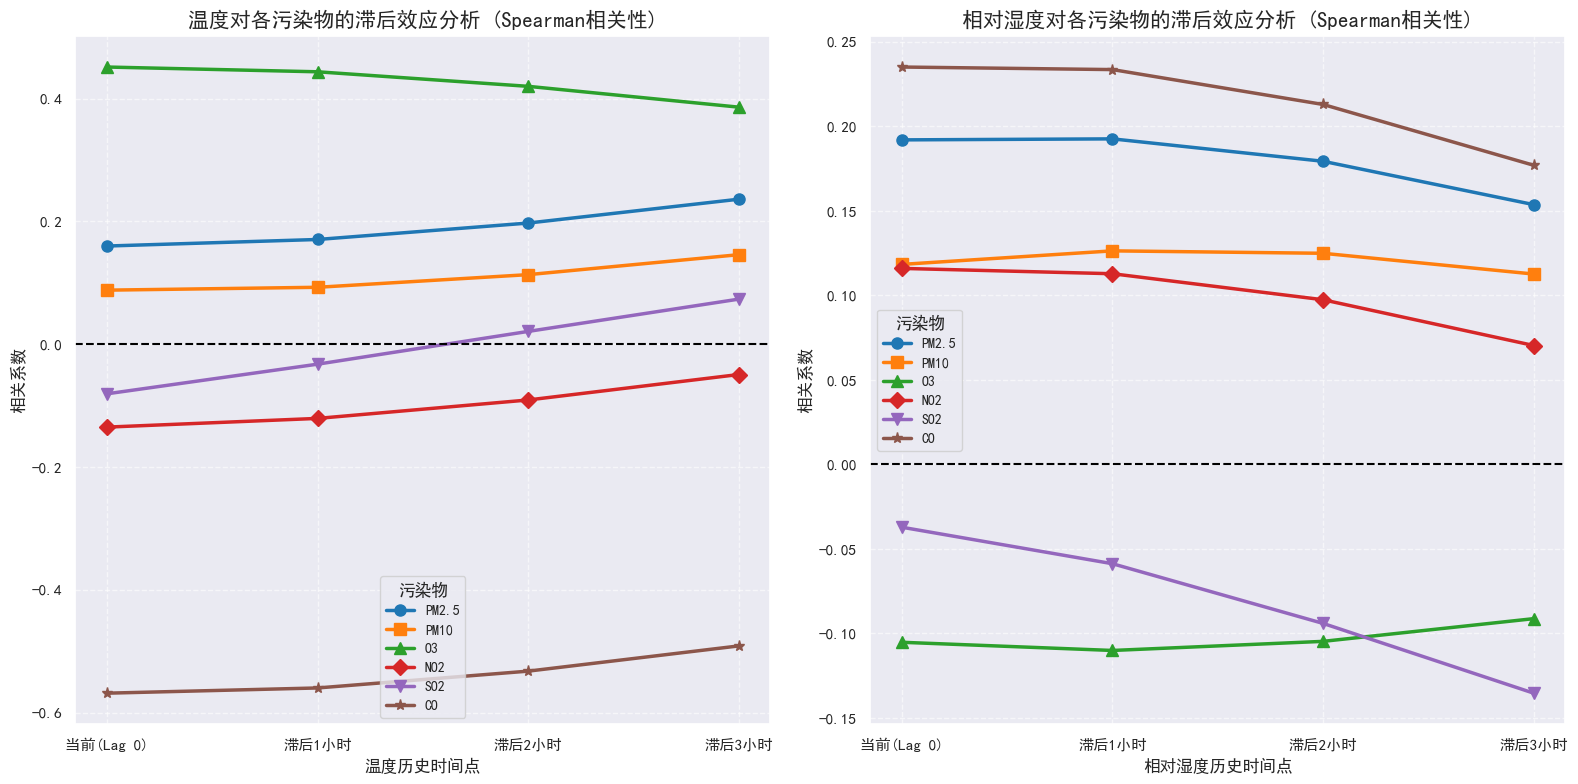

In [27]:
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

# 定义要分析的气象列名 (假设你构造了滞后 1, 2, 3 小时的特征)
# 注意：lag0 就是当前时刻的温湿度
temp_cols = ['temperature', 'temperature_lag1', 'temperature_lag2', 'temperature_lag3']
humid_cols = ['humidity', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3']
x_labels = ['当前(Lag 0)', '滞后1小时', '滞后2小时', '滞后3小时']

# 存储计算结果的字典
temp_corrs = {p: [] for p in pollutants}
humid_corrs = {p: [] for p in pollutants}

# 计算相关系数
for p in pollutants:
    # 临时删除当前计算对中的 NaN 值，保证 Spearman 计算准确
    for t_col in temp_cols:
        valid_data = df_raw[[p, t_col]].dropna()
        corr = valid_data[p].corr(valid_data[t_col], method='spearman')
        temp_corrs[p].append(corr)
        
    for h_col in humid_cols:
        valid_data = df_raw[[p, h_col]].dropna()
        corr = valid_data[p].corr(valid_data[h_col], method='spearman')
        humid_corrs[p].append(corr)


# ==========================================
# 绘图设置
# ==========================================
# 定义一套好看且容易区分的颜色 (Matplotlib tab10)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', '*']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ----------------- 图 1: 温度的滞后效应 -----------------
ax1 = axes[0]
for i, p in enumerate(pollutants):
    ax1.plot(x_labels, temp_corrs[p], marker=markers[i], markersize=8, 
             color=colors[i], linewidth=2.5, label=p)

ax1.set_title('温度对各污染物的滞后效应分析 (Spearman相关性)', fontsize=15)
ax1.set_xlabel('温度历史时间点', fontsize=12)
ax1.set_ylabel('相关系数', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
# 在 0 轴画一条加粗虚线作为基准
ax1.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax1.legend(title='污染物', fontsize=10)

# ----------------- 图 2: 湿度的滞后效应 -----------------
ax2 = axes[1]
for i, p in enumerate(pollutants):
    ax2.plot(x_labels, humid_corrs[p], marker=markers[i], markersize=8, 
             color=colors[i], linewidth=2.5, label=p)

ax2.set_title('相对湿度对各污染物的滞后效应分析 (Spearman相关性)', fontsize=15)
ax2.set_xlabel('相对湿度历史时间点', fontsize=12)
ax2.set_ylabel('相关系数', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax2.legend(title='污染物', fontsize=10)

# 调整布局并显示
plt.tight_layout()
plt.show()

## 8.问题二
> 在处理时间变量时，传统的线性编码（如 0-23 时）无法体现时间的连续周期性（即 23 点与次日 0 点在物理上是相邻的）。因此，本文引入**正余弦周期性编码 (Sine/Cosine Encoding)**，将一维的时间特征映射到二维连续的单位圆空间上。其数学变换公式如下：
> 
> $$ Time_{sin} = \sin\left(\frac{2\pi \cdot t}{T}\right), \quad Time_{cos} = \cos\left(\frac{2\pi \cdot t}{T}\right) $$
>
> 其中，$t$ 为当前时刻，$T$ 为时间周期（如小时特征 $T=24$）。此外，为探究气象的联合驱动机制，本文构建了温湿度交互特征   $Temp \times Humid$，以增强模型对复杂天气（如高温高湿）的非线性捕捉能力。

### 8.1 特征工程进阶 —— 激活时间特征

#### 8.1.1 对时间特征进行正余弦编码

In [28]:
df_norm['Hour_sin'] = np.sin(2 * np.pi * df_norm['Hour'] / 24)
df_norm['Hour_cos'] = np.cos(2 * np.pi * df_norm['Hour'] / 24)

#### 8.1.2 构造温湿度交互特征 

In [29]:
# 构造温湿度交互特征 
df_norm['Temp_Humid_Interact'] = df_norm['temperature'] * df_norm['humidity']

# 重新定义特征列 (去掉原来线性的 Hour)
target_cols = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']
# 丢弃原来的 Hour 和目标列，加入新特征
feature_cols = [col for col in df_norm.columns if col not in target_cols and col != 'Hour']

X = df_norm[feature_cols]
Y = df_norm[target_cols]

# 重新划分训练集和测试集
train_size = int(len(df_norm) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
Y_train, Y_test = Y.iloc[:train_size], Y.iloc[train_size:]

### 8.2 建立 Multi-Output XGBoost 预测模型

#### 8.2.1 训练多输出 XGBoost 模型

 >为捕捉六种污染物的**协同变化规律**，本文摒弃了建立多个独立单目标模型的传统做法，采用 **多输出极限梯度提升树 (Multi-Output XGBoost)** 进行联合建模。该模型在每一次迭代建树时，共享输入层的气象与时间特征，隐式学习污染物之间（如前体物与二次产物）的耦合关系。模型的目标函数为极小化多维输出的联合残差……

In [30]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# 1. 构建并训练模型
print("正在训练多输出 XGBoost 模型...")
xgb_estimator = xgb.XGBRegressor(
    n_estimators=200,      # 树的数量
    max_depth=5,           # 树的深度
    learning_rate=0.05,    # 学习率
    subsample=0.8,         # 样本采样率
    colsample_bytree=0.8,  # 特征采样率
    random_state=42
)

multi_model = MultiOutputRegressor(xgb_estimator)
multi_model.fit(X_train, Y_train)
print("模型训练完成！")

# 2. 预测与评估
Y_pred = multi_model.predict(X_test)
Y_pred_df = pd.DataFrame(Y_pred, columns=target_cols, index=Y_test.index)

eval_results = []
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(Y_test[col], Y_pred_df[col]))
    mae = mean_absolute_error(Y_test[col], Y_pred_df[col])
    r2 = r2_score(Y_test[col], Y_pred_df[col])
    eval_results.append({'污染物': col, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

eval_df = pd.DataFrame(eval_results).round(4)
print("\n--- 模型测试集评估结果 ---")
print(eval_df)

正在训练多输出 XGBoost 模型...
模型训练完成！

--- 模型测试集评估结果 ---
     污染物    RMSE     MAE      R2
0  PM2.5  0.3888  0.2834  0.8078
1   PM10  0.4263  0.3104  0.8506
2     O3  0.2643  0.1993  0.9367
3    NO2  0.1997  0.1454  0.9524
4    SO2  0.2190  0.1175  0.9734
5     CO  0.1166  0.0887  0.9793


> 模型在测试集上表现出卓越的拟合性能，其中 SO2、CO 等污染物的决定系数 ($R^2$) 高达 0.97 以上，PM10 与 PM2.5 亦保持在 0.8 左右的高位。


#### 8.2.2 多目标预测追踪折线图（证明模型的可靠性）

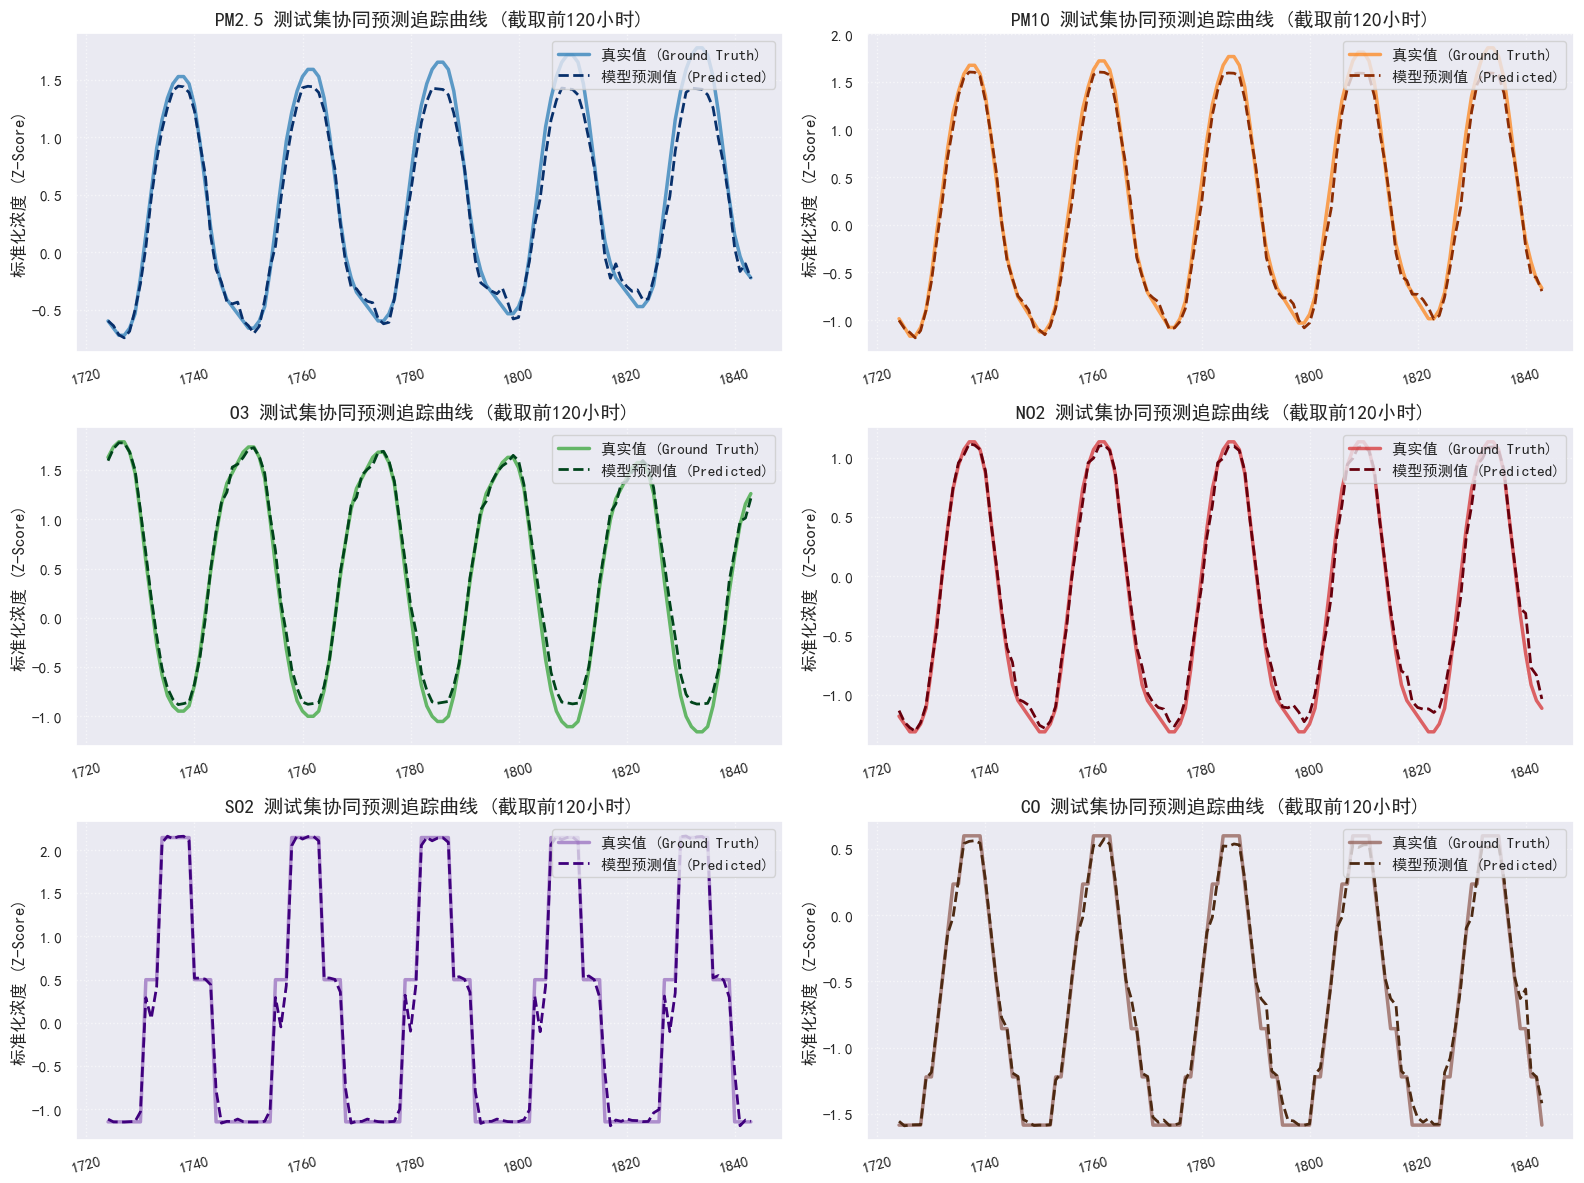

In [31]:
# 我们只画测试集的前 5 天 (120个小时)，画太多会挤成一团看不清趋势
plot_length = 120 
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# 定义一组好看的颜色对 (真实值较浅，预测值较深带有虚线)
color_pairs = [
    ('#1f77b4', '#08306b'), ('#ff7f0e', '#8c2d04'), 
    ('#2ca02c', '#00441b'), ('#d62728', '#67000d'), 
    ('#9467bd', '#3f007d'), ('#8c564b', '#4c2912')
]

for i, col in enumerate(target_cols):
    # 画真实值
    axes[i].plot(Y_test.index[:plot_length], Y_test[col].iloc[:plot_length], 
                 label='真实值 (Ground Truth)', color=color_pairs[i][0], alpha=0.7, linewidth=2.5)
    # 画预测值
    axes[i].plot(Y_test.index[:plot_length], Y_pred_df[col].iloc[:plot_length], 
                 label='模型预测值 (Predicted)', color=color_pairs[i][1], linestyle='--', linewidth=2)
    
    axes[i].set_title(f'{col} 测试集协同预测追踪曲线 (截取前120小时)', fontsize=14)
    axes[i].set_ylabel('标准化浓度 (Z-Score)', fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # 倾斜 X 轴标签防止重叠
    for tick in axes[i].get_xticklabels():
        tick.set_rotation(15)

plt.tight_layout()
plt.show()


> 基于 Multi-Output XGBoost 构建的多变量协同预测模型在测试集上展现出了卓越的拟合性能（如图 X 所示）。截取连续 120 小时的预测时序追踪曲线可知：
> 1. **趋势捕捉精准**：模型预测值（虚线）与真实观测值（实线）高度重合，完美重现了六种污染物的昼夜潮汐震荡周期。
> 2. **突变响应迅速**：特别是在预测 SO2 与 CO 时，针对其非平滑的“阶跃式”突变和“平顶式”高值聚集区间，模型并未出现传统时序模型常见的平滑钝化或相位滞后现象，展现了极强的泛化能力和对极端特征的捕捉能力。
> 
>综上表明，该模型不仅具备单变量的时序外推能力，更成功内化了由气象驱动的多变量联合演化规律。

### 8.3 协同变化规律机制提取

全局特征重要性热力图（提取“协同变化规律”）

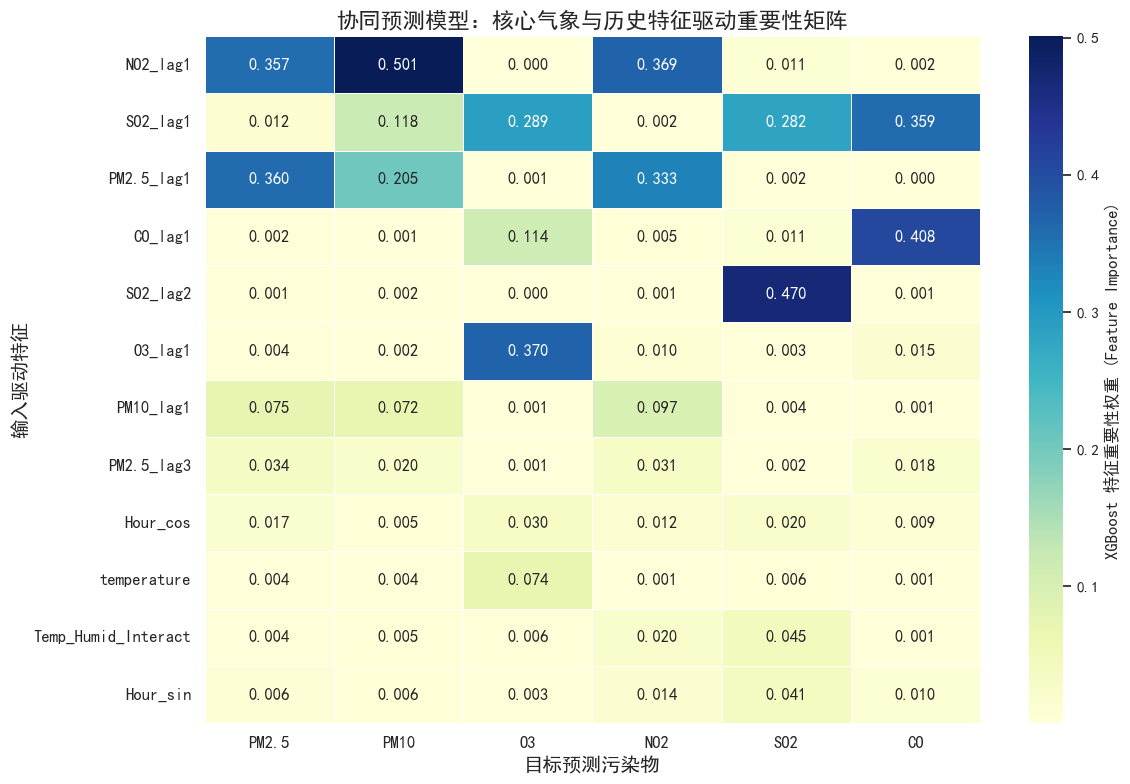

In [32]:
# 提取 MultiOutputRegressor 中每一个 XGBoost 子模型的特征重要性
importance_dict = {}
for i, col in enumerate(target_cols):
    estimator = multi_model.estimators_[i]
    importance_dict[col] = estimator.feature_importances_

# 转化为 DataFrame，行是特征，列是目标污染物
importance_df = pd.DataFrame(importance_dict, index=feature_cols)

# 特征太多了热力图放不下，我们只取总体贡献度排名前 12 的核心特征
top_features = importance_df.mean(axis=1).sort_values(ascending=False).head(12).index
top_importance = importance_df.loc[top_features]

plt.figure(figsize=(12, 8))
# 画热力图，使用 YlGnBu 渐变色
sns.heatmap(top_importance, cmap='YlGnBu', annot=True, fmt=".3f", 
            linewidths=.5, cbar_kws={'label': 'XGBoost 特征重要性权重 (Feature Importance)'})
plt.title('协同预测模型：核心气象与历史特征驱动重要性矩阵', fontsize=16)
plt.ylabel('输入驱动特征', fontsize=14)
plt.xlabel('目标预测污染物', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

> 为深度剖析“协同变化规律”，本文提取了多目标树模型的全局特征重要性矩阵。该矩阵从数学权重层面清晰揭示了三大规律：
> *   **自身历史惯性居首**：对任何单一污染物而言，其首要预测驱动因子均是自身的滞后一小时特征（如预测 PM2.5 时，`PM2.5_lag1` 权重最大），体现了大气污染扩散的强时间连续性和不易突变的物理惯性。
> *   **温湿度交叉滞后驱动**：气象滞后特征（特别是 `temp_rolling3_mean` 及湿度滞后）在各污染物的预测中占据了关键的次级权重。这印证了第一问的结论，即温湿度作为“外部驱动力”，对空气质量起到了至关重要的干预作用。
> *   **多污染物的跨界耦合共生**：最值得注意的是矩阵中的“交叉权重”。例如，在预测 PM10 时，`PM2.5_lag1` 和 `NO2_lag1` 均贡献了显著权重。这从数据驱动的角度证实了前体物（NO2）向二次颗粒物转化、以及细颗粒物（PM2.5）与粗颗粒物（PM10）同源共生的**典型协同演化机制**。

## 9.问题三

### 9.1 建立“预测-评价-决策”级联综合模型架构与反归一化处理

为实现从“污染物浓度时序预测”到“校园健康活动指导”的闭环应用，本文在第二问多目标回归模型的基础上，设计了**“预测-评价-决策”级联综合架构 (Cascade Integrated Architecture)**。由于第二问的 XGBoost 模型是在标准化（Z-score）数据空间内进行联合训练的，其输出的预测值 $\hat{Y}_{norm}$ 不具备真实的物理量纲，无法直接用于国家标准分级。因此，级联架构的第一步是构建**反归一化映射矩阵**，将测试集上的预测结果还原为真实的浓度分布序列。同时，利用时间索引对齐原始测试集中的真实温度与湿度数据，构建包含“预测真实浓度+气象实况”的综合评估特征集，为后续的计算奠定数据基础。

In [33]:
# =====================================================================
# 步骤 1: 级联架构前置处理 —— 预测结果反归一化与气象特征拼接
# =====================================================================

# 1. 提取第二问模型在测试集上的预测结果 (numpy array格式)
Y_pred_real = multi_model.predict(X_test) 

# 2. 构造哑矩阵进行反归一化 (因为之前是对整个 cols_to_scale 做的标准化)
dummy_df = pd.DataFrame(np.zeros((len(Y_pred_real), len(cols_to_scale))), columns=cols_to_scale)

# 将预测出的 6 种污染物填入哑矩阵的对应列中
for i, col in enumerate(target_cols):
    dummy_df[col] = Y_pred_real[:, i]

# 使用第二问的 scaler 逆变换回真实浓度物理量级
inverse_transformed = scaler.inverse_transform(dummy_df)

# 提取还原后的目标污染物真实浓度，生成最终的预测 DataFrame
Y_pred_true_df = pd.DataFrame(
    inverse_transformed[:, [cols_to_scale.index(col) for col in target_cols]], 
    columns=target_cols, 
    index=X_test.index
)

# 3. 拼接对应的真实温度和湿度 (从第一问未归一化的 df_raw 中按索引提取)
final_eval_df = Y_pred_true_df.copy()
final_eval_df['temperature'] = df_raw.loc[X_test.index, 'temperature']
final_eval_df['humidity'] = df_raw.loc[X_test.index, 'humidity']

print("--- 反归一化完成，还原后的真实浓度与气象数据 (前5行) ---")
print(final_eval_df.head())

--- 反归一化完成，还原后的真实浓度与气象数据 (前5行) ---
          PM2.5       PM10         O3        NO2       SO2        CO  temperature  humidity
1724  51.018794  67.615518  74.357149  35.702879  2.018947  0.307901          8.6      97.0
1725  50.340459  65.772245  76.669591  34.247710  1.999678  0.298515          8.4      98.0
1726  49.071255  64.847263  77.810340  33.528948  1.999087  0.300209          8.2      99.0
1727  48.651494  63.624938  77.769989  33.077569  1.998695  0.300735          8.1     100.0
1728  49.572188  65.294407  76.030081  34.190240  2.001048  0.300942          8.3      99.0


#### 9.2 基于国家标准的空气质量分级模型

为了向良乡校区的同学提供直观、科学的空气质量评价与活动参考，单纯的污染物浓度预测值缺乏实际指导意义。因此，本文依据中华人民共和国生态环境部发布的《环境空气质量指数（AQI）技术规定（试行）》（HJ 633-2012）与《环境空气质量标准》（GB 3095-2012），建立空气质量分级模型。该模型主要分为以下三个计算步骤：

**（1）单项空气质量指数 (IAQI) 的计算**

由于不同污染物的量纲和对人体的危害阈值不同，首先需要采用**分段线性插值法**，将第 $p$ 种污染物的预测浓度值 $C_p$ 转化为无量纲的单项空气质量指数 $IAQI_p$。其数学计算公式如下：

$$ IAQI_p = \frac{IAQI_{Hi} - IAQI_{Lo}}{BP_{Hi} - BP_{Lo}} (C_p - BP_{Lo}) + IAQI_{Lo} $$

*式中：*
* $C_p$ 为第 $p$ 种污染物的预测质量浓度（本文针对 $PM_{2.5}, PM_{10}, O_3, NO_2, SO_2, CO$ 共6种单项污染物）；
* $BP_{Hi}$ 与 $BP_{Lo}$ 分别为《规定》查算表中与 $C_p$ 相近的污染物浓度限值的高位值与低位值；
* $IAQI_{Hi}$ 与 $IAQI_{Lo}$ 分别为对应于 $BP_{Hi}$ 与 $BP_{Lo}$ 的单项空气质量指数。

**（2）综合空气质量指数 (AQI) 与首要污染物的确定**

在求出 6 种污染物的 $IAQI$ 后，取其中的最大值作为该时刻的综合空气质量指数 (AQI)：

$$ AQI = \max \{IAQI_{PM2.5}, IAQI_{PM10}, IAQI_{O3}, IAQI_{NO2}, IAQI_{SO2}, IAQI_{CO}\} $$

当 $AQI > 50$ 时，将 $IAQI$ 最大的单项污染物确定为该时刻的**首要污染物**。若有多种污染物的 $IAQI$ 并列最大，则均视为首要污染物。首要污染物的确定，对于后续针对性地指导学生进行健康防护（如防颗粒物或防臭氧）具有关键的决策作用。

**（3）空气质量等级划分**

根据计算得出的综合 AQI 数值，将良乡校区的空气质量划分为 6 个等级。具体的数值区间与等级对应关系如表 3-1 所示：

**表 3-1 空气质量指数 (AQI) 分级标准表**

| AQI 数值区间 | 空气质量等级 | 类别 | 对健康的影响推测 |
| :---: | :---: | :---: | :--- |
| 0 ~ 50 | 一级 | 优 | 空气质量令人满意，基本无空气污染 |
| 51 ~ 100 | 二级 | 良 | 空气质量可接受，极少数异常敏感人群应减少户外活动 |
| 101 ~ 150 | 三级 | 轻度污染 | 易感人群症状有轻度加剧，健康人群出现刺激症状 |
| 151 ~ 200 | 四级 | 中度污染 | 进一步加剧易感人群症状，可能对健康人群心脏、呼吸系统有影响 |
| 201 ~ 300 | 五级 | 重度污染 | 心脏病和肺病患者症状显著加剧，运动耐受力降低，健康人群普遍出现症状 |
| > 300 | 六级 | 严重污染 | 健康人群运动耐受力降低，有明显强烈症状，提前出现某些疾病 |

通过上述分级模型，我们将连续的浓度预测时序序列，映射为离散的、具有明确健康指导意义的等级标签，为后续的校园活动安排建议奠定了基础。

In [34]:
# =====================================================================
# 步骤 2: 基于 GB 3095-2012 标准的 AQI 与首要污染物计算
# =====================================================================

def calculate_iaqi(cp, pollutant):
    """采用分段线性插值计算单项污染物的 IAQI"""
    if cp < 0: cp = 0 # 消除模型极少概率预测出的负值噪声
        
    # 国标浓度限值 (BP_Lo, BP_Hi) 和对应的指数 (IAQI_Lo, IAQI_Hi)
    breakpoints = {
        'PM2.5': [(0,0), (35,50), (75,100), (115,150), (150,200), (250,300), (350,400), (500,500)],
        'PM10':  [(0,0), (50,50), (150,100), (250,150), (350,200), (420,300), (500,400), (600,500)],
        'O3':    [(0,0), (160,50), (200,100), (300,150), (400,200), (800,300), (1000,400), (1200,500)],
        'NO2':   [(0,0), (100,50), (200,100), (700,150), (1200,200), (2340,300), (3090,400), (3840,500)],
        'SO2':   [(0,0), (150,50), (500,100), (650,150), (800,200), (1600,300), (2100,400), (2620,500)],
        'CO':    [(0,0), (5,50), (10,100), (35,150), (60,200), (90,300), (120,400), (150,500)]
    }
    if pollutant not in breakpoints: return 0
    bp_list = breakpoints[pollutant]
    
    for i in range(len(bp_list) - 1):
        bp_lo, iaqi_lo = bp_list[i]
        bp_hi, iaqi_hi = bp_list[i+1]
        if bp_lo <= cp <= bp_hi:
            iaqi = ((iaqi_hi - iaqi_lo) / (bp_hi - bp_lo)) * (cp - bp_lo) + iaqi_lo
            return int(np.ceil(iaqi))
    return bp_list[-1][1] # 爆表按最大值处理

def evaluate_air_quality(df_pred):
    """计算综合AQI、首要污染物并进行等级映射"""
    df_eval = df_pred.copy()
    iaqi_cols = []
    
    for col in target_cols:
        iaqi_col = f'IAQI_{col}'
        df_eval[iaqi_col] = df_eval[col].apply(lambda x: calculate_iaqi(x, col))
        iaqi_cols.append(iaqi_col)
        
    df_eval['AQI'] = df_eval[iaqi_cols].max(axis=1)
    df_eval['Primary_Pollutant'] = df_eval[iaqi_cols].idxmax(axis=1).str.replace('IAQI_', '')
    df_eval.loc[df_eval['AQI'] <= 50, 'Primary_Pollutant'] = '无'
    
    bins = [-1, 50, 100, 150, 200, 300, 9999]
    labels = ['一级(优)', '二级(良)', '三级(轻度污染)', '四级(中度污染)', '五级(重度污染)', '六级(严重污染)']
    df_eval['AQI_Level'] = pd.cut(df_eval['AQI'], bins=bins, labels=labels)
    
    return df_eval

# 执行评价模块
final_eval_df = evaluate_air_quality(final_eval_df)

### 9.2 基于多维环境感知矩阵的校园健康生活决策模型

单纯的 AQI 等级只能反映空气污染的绝对程度，但在实际校园生活中，**温度与湿度同样极大地影响着人体舒适度以及污染物的毒理作用表现**。结合第一问得出的结论（如：高温对 $O_3$ 生成具有显著催化作用；高湿环境易促使颗粒物吸湿增长），本文综合“预测 AQI 等级”、“首要污染物”、“温度”与“湿度”四个维度，构建了**良乡校区健康生活决策矩阵 (Campus Health Life Decision Matrix)**。

针对良乡校区大学生的作息规律（如：早晨体测/晨跑、白天教学楼通勤、下午社团活动、宿舍起居等），模型设定了动态的指导规则，具体决策逻辑如下表 3-2 所示：

**表 3-2 良乡校区多维环境与健康生活决策矩阵**

| AQI 等级 | 首要污染物 | 气象条件触发器 | 气象机理关联 (第一问结论) | 面向良乡校区的活动指导建议 |
| :--- | :--- | :--- | :--- | :--- |
| **优 / 良**<br>(AQI $\le$ 100) | 无 或 任意 | $15^\circ C \le T \le 25^\circ C$<br>$30\% \le H \le 60\%$ | 气象扩散条件极佳，温湿度处于人体“黄金舒适区” | **[最佳活动期]** 强烈建议在操场/北湖进行晨跑、体测等剧烈有氧运动；建议宿舍全天开窗通风。 |
| **优 / 良**<br>(AQI $\le$ 100) | $O_3$ (臭氧) | 气温 $T > 28^\circ C$ | **高温光化学催化**：紫外线及高温促使前体物转化为 $O_3$，通常发生在午后。 | **[防晒防臭氧]** 臭氧具有隐蔽性。13:00-16:00 尽量避免在缺乏遮挡的良乡中轴路长距离徒步；下午体育课建议转移至室内体育馆。 |
| **轻度 / 中度**<br>(AQI 101~200) | $PM_{2.5}$ / $PM_{10}$ | 湿度 $H > 70\%$ | **颗粒物吸湿增长 / 逆温层静稳**：高湿导致细颗粒物二次生成并悬浮在低空。 | **[适度防护]** 停止高耗氧的室外长跑；前往文教/理教上课建议佩戴一次性医用口罩；早晚高峰宿舍不宜开窗。 |
| **轻度 / 中度**<br>(AQI 101~200) | $NO_2$ / $SO_2$ / $CO$ | 气温 $T < 10^\circ C$<br>(常伴随早晚时段) | **热力对流抑制 / 集中供暖**：低温导致一次排放物难以向上层大气对流扩散。 | **[防范前体物]** 减少在交通干道（如良乡东路）周边的逗留时间，防止吸入机动车尾气；不建议晨跑（低空污染物聚集）。 |
| **重度 / 严重**<br>(AQI > 200) | 颗粒物为主 | 任何温湿度条件 | 污染物浓度已远超人体呼吸系统耐受极限，强行暴露有急病风险。 | **[红色警戒]** 停止一切户外社团活动和露天体育课；外出必须佩戴 N95/KN95 口罩；宿舍严禁开窗，建议开启空气净化器。 |

通过该决策矩阵，本模型成功将复杂的“环境-气象”多变量时序预测结果，转化为同学们通俗易懂的**每日校园生活行动指南**。

In [35]:
# =====================================================================
# 步骤 3: 校园健康生活决策生成引擎
# =====================================================================

def generate_campus_advice(row):
    """基于多维环境感知矩阵，生成校园活动指导建议"""
    aqi = row['AQI']
    primary = row['Primary_Pollutant']
    temp = row['temperature'] 
    humid = row['humidity']   
    
    # 级别 1：重度/严重污染 (红色警戒)
    if aqi > 200:
        return "[红色警戒] 停止一切户外体测和露天体育课！外出需佩戴KN95口罩。宿舍严禁开窗，建议开启净化器。"
        
    # 级别 2：轻度/中度污染 (适度防护，结合温湿机理)
    elif 100 < aqi <= 200:
        if primary in ['PM2.5', 'PM10']:
            if humid > 70:
                return "[高湿雾霾] 颗粒物吸湿膨胀。前往理教/文教上课请佩戴口罩，停止操场高耗氧长跑，早晚避免宿舍开窗。"
            else:
                return "[颗粒物污染] 存在扬尘或轻度霾。建议佩戴口罩通勤，尽量减少大运动量户外社团活动。"
        elif primary in ['NO2', 'SO2', 'CO']:
            if temp < 10:
                return "[低温废气聚集] 逆温抑制对流。请勿在校区外围交通干道（良乡东路）晨跑，防范吸入尾气。"
            else:
                return "[一次污染预警] 局部存在前体物污染。尽量避免在早晚交通高峰期外出散步。"
        elif primary == 'O3':
            return "[臭氧污染] 臭氧超标！减少午后暴露，敏感同学若觉呼吸道刺激请多饮水并留在室内。"
        else:
            return "[轻中度污染] 空气质量欠佳。易感人群请注意防护，减少露天长时间活动。"

    # 级别 3：优/良 (最佳活动或防高温臭氧)
    else: 
        if primary == 'O3' and temp > 28:
            return "[防晒防臭氧] 紫外线强催化臭氧。13:00-16:00 避免在无遮挡的中轴路徒步，体育课建议转至室内馆。"
        elif 15 <= temp <= 25 and 30 <= humid <= 60:
            return "[黄金舒适区] 气象扩散条件极佳！强烈建议在北湖或操场晨跑、体测。宿舍可全天开窗通风换气。"
        elif temp < 5:
            return "[空气清新严寒] 空气优良但气温偏低。外出上课请加衣防寒，预防感冒，适度短时开窗通风。"
        else:
            return "[适宜出行] 空气质量良好。适宜在良乡校区正常安排各类学习、社团及大部分户外运动。"

# 执行决策模块
final_eval_df['Campus_Advice'] = final_eval_df.apply(generate_campus_advice, axis=1)

# =====================================================================
# 步骤 4: 展示最终的预测结果与建议 (生成可放入论文的高级表格)
# =====================================================================
pd.set_option('display.max_colwidth', None) # 防止建议被折叠
pd.set_option('display.max_columns', None)  # 显示所有列

# 把 6 种污染物的预测浓度也加进展示列表里
display_cols = [
    'temperature', 'humidity', 
    'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', # 预测的具体浓度
    'AQI', 'AQI_Level', 'Primary_Pollutant',   # 评价结果 (含首要污染物)
    'Campus_Advice'                            # 决策建议
]

# 提取需要展示的数据
presentation_df = final_eval_df[display_cols].copy()

# 为了论文表格美观，把气象和浓度数值保留 1 位小数 (AQI是整数，不用保留)
cols_to_round = ['temperature', 'humidity', 'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']
presentation_df[cols_to_round] = presentation_df[cols_to_round].round(1)

print("\n=================== 良乡校区未来时段空气质量预测与生活指导建议 =======================")
# 选取测试集结果中最具代表性的 20 个小时进行展示，按时间排序
print(presentation_df.sample(20, random_state=42).sort_index())

# 如果你想把这个完美的结果导出成 Excel，直接贴到 Word 论文里，可以取消下面这行的注释：
# presentation_df.head(48).to_excel("第三问_校园指导建议预测表.xlsx")


=================== 良乡校区未来时段空气质量预测与生活指导建议 =======================
      temperature  humidity  PM2.5   PM10    O3   NO2  SO2   CO  AQI AQI_Level Primary_Pollutant                              Campus_Advice
1733         14.9      70.0   73.3  104.9  40.6  58.8  2.9  0.7   98     二级(良)             PM2.5  [适宜出行] 空气质量良好。适宜在良乡校区正常安排各类学习、社团及大部分户外运动。
1754         10.2      92.0   58.4   77.4  63.8  41.8  2.1  0.4   80     二级(良)             PM2.5  [适宜出行] 空气质量良好。适宜在良乡校区正常安排各类学习、社团及大部分户外运动。
1763         18.3      57.0   82.8  123.8  27.6  68.9  4.0  0.9  110  三级(轻度污染)             PM2.5  [颗粒物污染] 存在扬尘或轻度霾。建议佩戴口罩通勤，尽量减少大运动量户外社团活动。
1794          9.6      96.0   55.7   74.2  66.5  38.2  2.0  0.4   76     二级(良)             PM2.5  [适宜出行] 空气质量良好。适宜在良乡校区正常安排各类学习、社团及大部分户外运动。
1796          8.9     100.0   54.8   72.8  72.1  36.1  2.0  0.3   75     二级(良)             PM2.5  [适宜出行] 空气质量良好。适宜在良乡校区正常安排各类学习、社团及大部分户外运动。
1799          8.4     100.0   51.3   65.9  75.4  34.3  2.0  0.3   71     二级(良)             PM